In [ ]:
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip -q '/content/drive/MyDrive/fruit Ninja dataset.v1i.yolov8.zip' -d '/content/Fruit Ninja Final DataSet'

In [ ]:
!wget -O /content/train_val_split.py https://raw.githubusercontent.com/EdjeElectronics/Train-and-Deploy-YOLO-Models/refs/heads/main/utils/train_val_split.py

!python train_val_split.py --datapath="/content/Fruit Ninja Final DataSet" --train_pct=0.9

--2026-01-26 11:28:51--  https://raw.githubusercontent.com/EdjeElectronics/Train-and-Deploy-YOLO-Models/refs/heads/main/utils/train_val_split.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3203 (3.1K) [text/plain]
Saving to: ‘/content/train_val_split.py’

/content/train_val_ 100%[===================>]   3.13K  --.-KB/s    in 0s      

2026-01-26 11:28:51 (66.0 MB/s) - ‘/content/train_val_split.py’ saved [3203/3203]

Created folder at /content/data/train/images.
Created folder at /content/data/train/labels.
Created folder at /content/data/validation/images.
Created folder at /content/data/validation/labels.
Number of image files: 955
Number of annotation files: 955
Images moving to train: 859
Images moving to validation: 96


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 80.9 MB/s eta 0:00:00


In [ ]:
# Python function to automatically create data.yaml config file
# 1. Reads "classes.txt" file to get list of class names
# 2. Creates data dictionary with correct paths to folders, number of classes, and names of classes
# 3. Writes data in YAML format to data.yaml

import yaml
import os

def create_data_yaml(path_to_classes_txt, path_to_data_yaml):

  # Read class.txt to get class names
  if not os.path.exists(path_to_classes_txt):
    print(f'classes.txt file not found! Please create a classes.txt labelmap and move it to {path_to_classes_txt}')
    return
  with open(path_to_classes_txt, 'r') as f:
    classes = []
    for line in f.readlines():
      if len(line.strip()) == 0: continue
      classes.append(line.strip())
  number_of_classes = len(classes)

  # Create data dictionary
  data = {
      'path': '/content/data',
      'train': 'train/images',
      'val': 'validation/images',
      'nc': number_of_classes,
      'names': classes
  }

  # Write data to YAML file
  with open(path_to_data_yaml, 'w') as f:
    yaml.dump(data, f, sort_keys=False)
  print(f'Created config file at {path_to_data_yaml}')

  return

# Define path to classes.txt and run function
path_to_classes_txt = '/content/Fruit Ninja Final DataSet/classes.txt'
path_to_data_yaml = '/content/data.yaml'

create_data_yaml(path_to_classes_txt, path_to_data_yaml)

print('\nFile contents:\n')
!cat /content/data.yaml

Created config file at /content/data.yaml

File contents:

path: /content/data
train: train/images
val: validation/images
nc: 2
names:
- Bomb
- Fruit


In [ ]:
!yolo detect train data=/content/data.yaml model=yolo11s.pt epochs=40 imgsz=640

Ultralytics 8.4.7 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0

In [ ]:
!yolo detect predict model=runs/detect/train/weights/best.pt source=data/validation/images save=True

Ultralytics 8.4.7 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s summary (fused): 101 layers, 9,413,574 parameters, 0 gradients, 21.3 GFLOPs

image 1/96 /content/data/validation/images/2025-12-31_15-28-56-359_jpeg.rf.1f591c479ba855f1b1935aeabb8b2a3c.jpg: 480x640 1 Bomb, 1 Fruit, 55.3ms
image 2/96 /content/data/validation/images/2025-12-31_15-29-05-422_jpeg.rf.e5b40e3f17c4f3a5bf4398859effab9c.jpg: 480x640 1 Fruit, 12.4ms
image 3/96 /content/data/validation/images/2025-12-31_15-31-59-051_jpeg.rf.2378d679c10a48391888129855ff3d65.jpg: 480x640 1 Bomb, 1 Fruit, 12.3ms
image 4/96 /content/data/validation/images/2025-12-31_15-32-02-051_jpeg.rf.d06971aa8ff07e094173b0bfb0b14659.jpg: 480x640 1 Bomb, 1 Fruit, 12.3ms
image 5/96 /content/data/validation/images/2025-12-31_15-32-03-050_jpeg.rf.dcb51bfe395684f28efbc1c6fb26c56e.jpg: 480x640 1 Bomb, 12.3ms
image 6/96 /content/data/validation/images/2025-12-31_15-33-25-362_jpeg.rf.f2b2e727a41b628aab95423074d31f46.jpg: 480x640 1 Fru

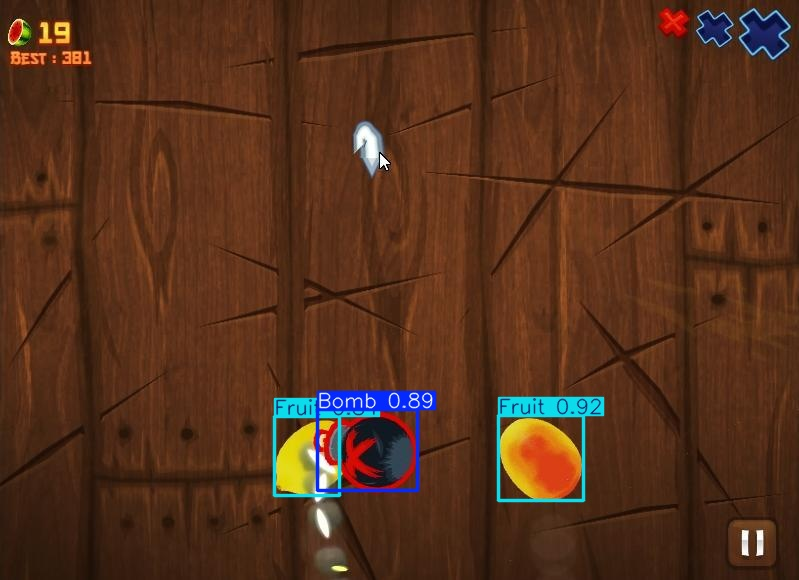

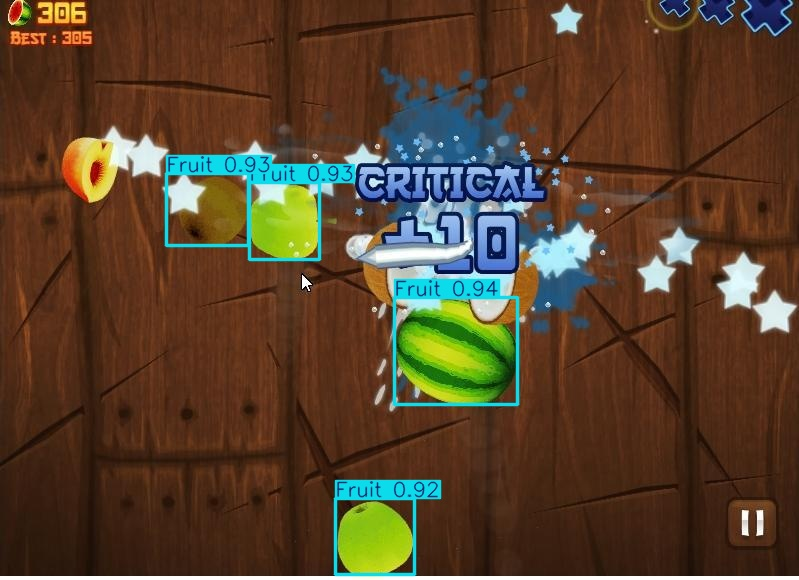

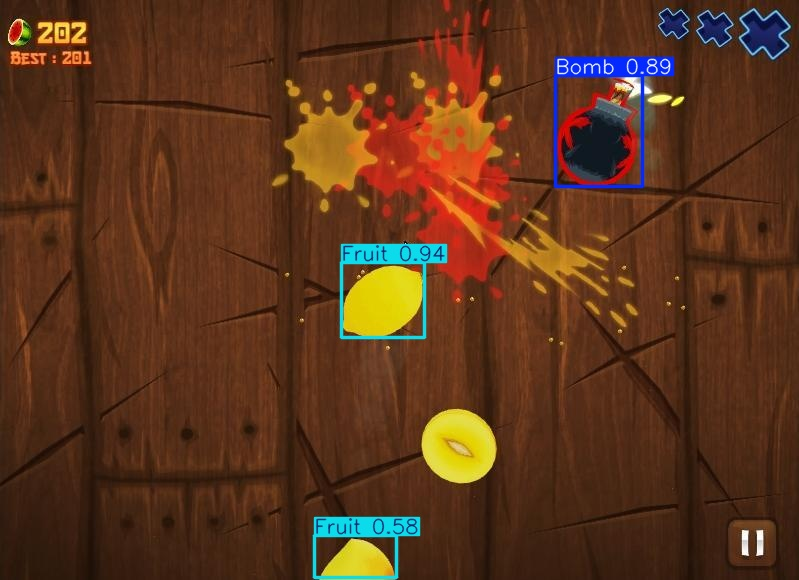

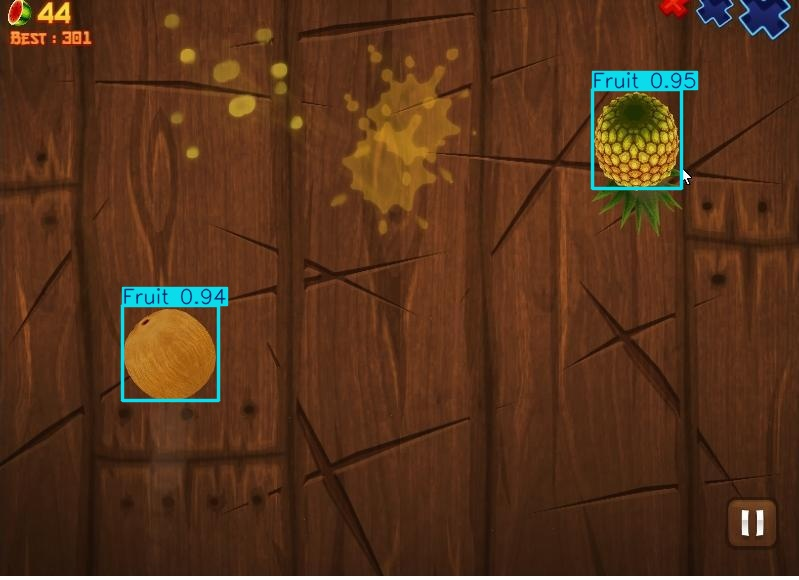

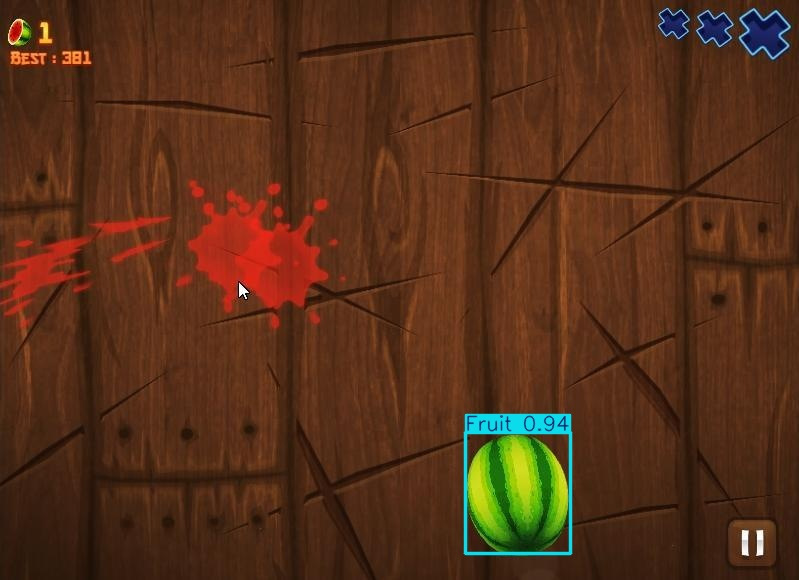

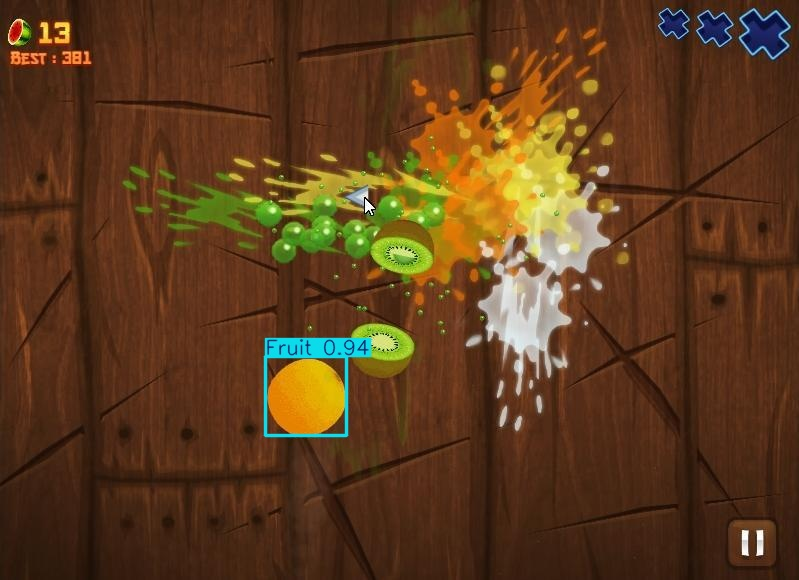

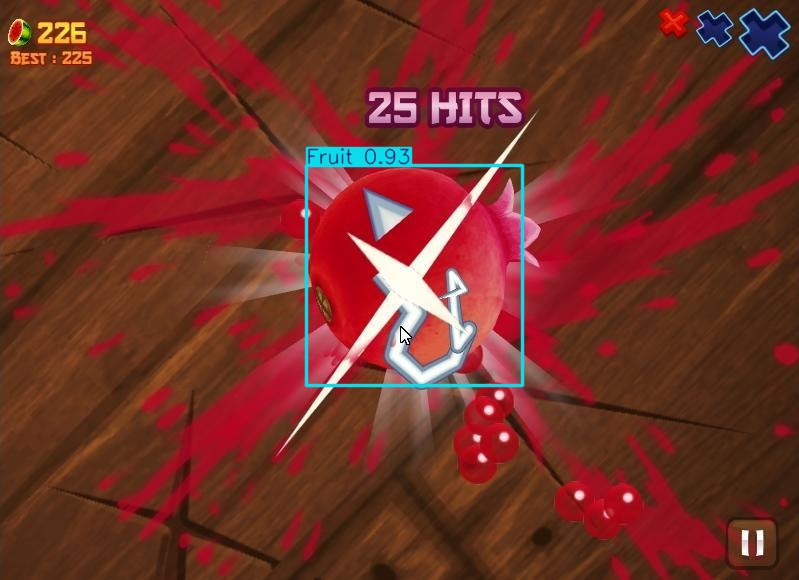

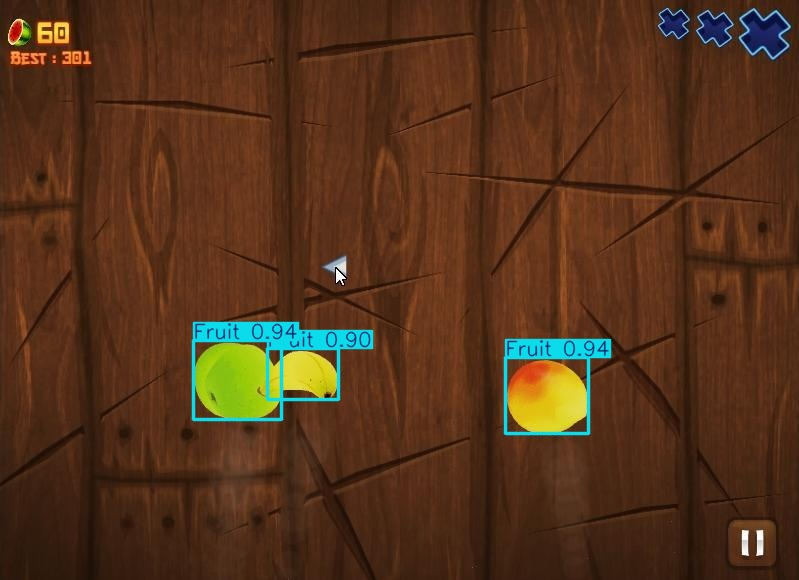

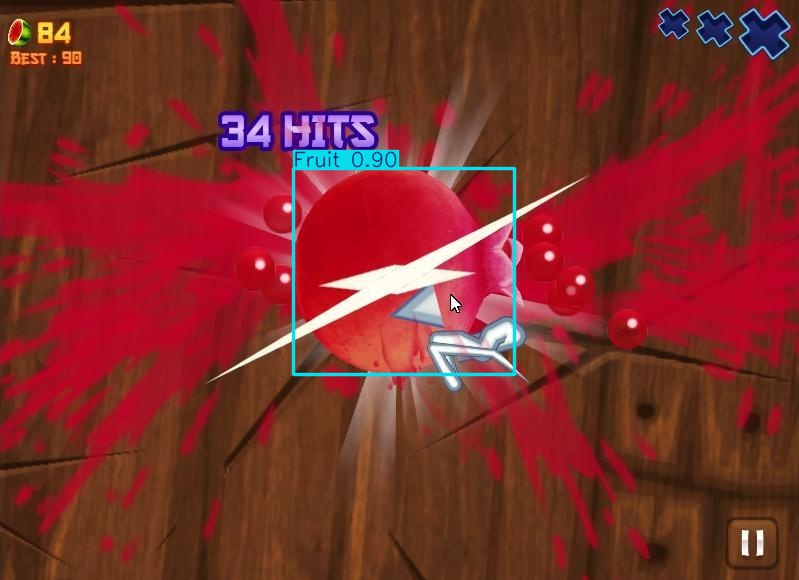

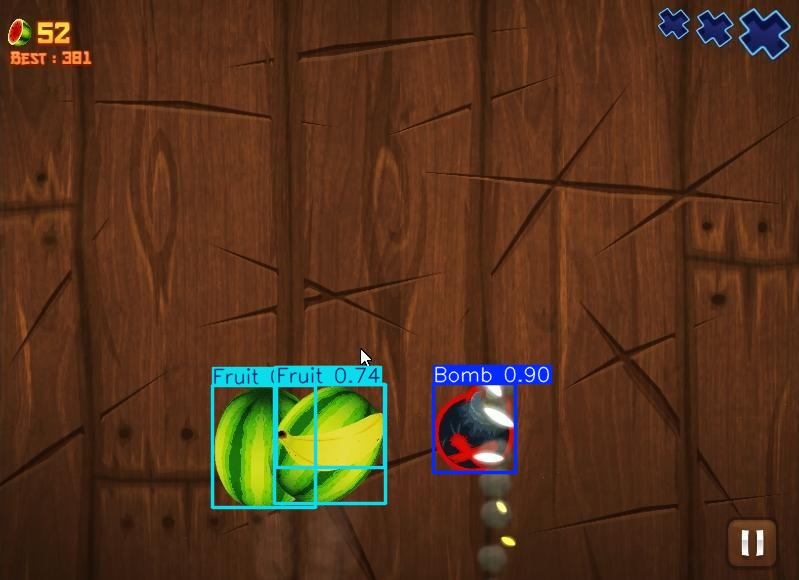

In [ ]:
import glob
from IPython.display import Image, display
for image_path in glob.glob(f'/content/runs/detect/predict/*.jpg')[:10]:
  display(Image(filename=image_path, height=400))
  print('\n')

In [ ]:
# Create "my_model" folder to store model weights and train results
!mkdir /content/my_model
!cp /content/runs/detect/train/weights/best.pt /content/my_model/my_model.pt
!cp -r /content/runs/detect/train /content/my_model

# Zip into "my_model.zip"
%cd my_model
!zip /content/my_model.zip my_model.pt
!zip -r /content/my_model.zip train
%cd /content

/content/my_model
  adding: my_model.pt (deflated 8%)
  adding: train/ (stored 0%)
  adding: train/BoxF1_curve.png (deflated 16%)
  adding: train/val_batch1_labels.jpg (deflated 12%)
  adding: train/results.csv (deflated 71%)
  adding: train/train_batch2.jpg (deflated 4%)
  adding: train/BoxP_curve.png (deflated 24%)
  adding: train/BoxR_curve.png (deflated 15%)
  adding: train/val_batch0_labels.jpg (deflated 13%)
  adding: train/confusion_matrix.png (deflated 37%)
  adding: train/train_batch1620.jpg (deflated 11%)
  adding: train/weights/ (stored 0%)
  adding: train/weights/last.pt (deflated 8%)
  adding: train/weights/best.pt (deflated 8%)
  adding: train/BoxPR_curve.png (deflated 21%)
  adding: train/val_batch1_pred.jpg (deflated 12%)
  adding: train/results.png (deflated 8%)
  adding: train/args.yaml (deflated 53%)
  adding: train/train_batch0.jpg (deflated 5%)
  adding: train/val_batch2_pred.jpg (deflated 14%)
  adding: train/train_batch1.jpg (deflated 5%)
  adding: train/train_ba

In [ ]:
# This takes forever for some reason, you can also just download the model from the sidebar
from google.colab import files

files.download('/content/my_model.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
sample_validation_image = '/content/data/validation/images/2026-01-05_13-49-41-159_jpeg.rf.ac1d82103149d34e9b2df22c85356b8c.jpg'

# Run prediction on a single sample image on the downloaded model
!yolo detect predict model=/content/my_model/my_model.pt source="{sample_validation_image}" save=True name=predict_sample

Ultralytics 8.4.7 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s summary (fused): 101 layers, 9,413,574 parameters, 0 gradients, 21.3 GFLOPs

image 1/1 /content/data/validation/images/2026-01-05_13-49-41-159_jpeg.rf.ac1d82103149d34e9b2df22c85356b8c.jpg: 480x640 1 Bomb, 3 Fruits, 89.6ms
Speed: 7.2ms preprocess, 89.6ms inference, 21.4ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict_sample2
💡 Learn more at https://docs.ultralytics.com/modes/predict


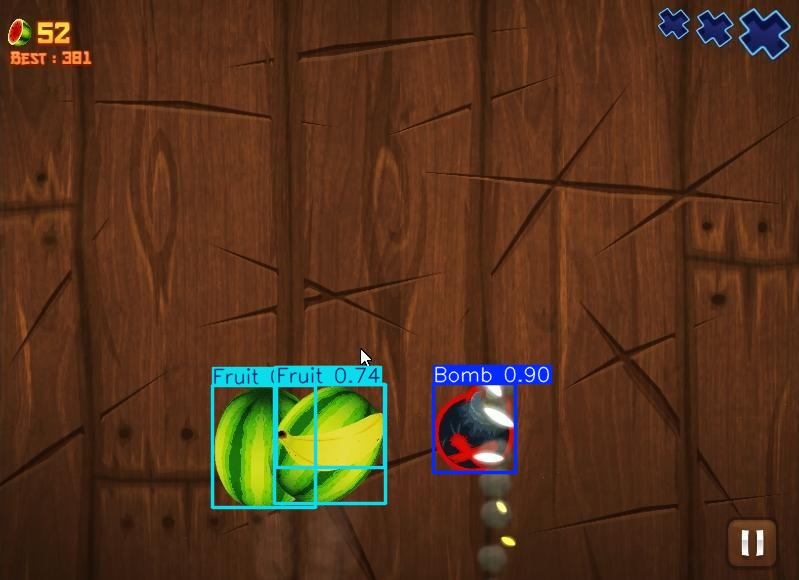

Predicted image saved at: /content/runs/detect/predict_sample/2026-01-05_13-49-41-159_jpeg.rf.ac1d82103149d34e9b2df22c85356b8c.jpg


In [ ]:


# Get the path to the predicted image
predicted_image_path = os.path.join('/content/runs/detect/predict_sample', os.path.basename(sample_validation_image))
display(Image(filename=predicted_image_path, height=400))
print(f"Predicted image saved at: {predicted_image_path}")